<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 1</center></b><h2>
<h3><b><center>El sistema solar como problema de los N-cuerpos</center></b><h3>
<h5><center><b>Asignada</b>: 14 de abril de 2025</center><h5>
<h5><center><b>Entrega</b>: 8 de mayo de 2025</center><h5>
<h7><center><i>Última actualización del profesor</b>: Lunes 14 de abril de 2025, 3:30 pm</i></center><h7>



<hr/>
<b>Nombre</b>: María Isabel Olarte García
<br/>
<b>Cédula</b>: 1034986320
<br/>
<b>Última actualización</b>: Jueves 15 de mayo de 2025, 3:20 am
<hr/>

## Enunciado

Vamos a poner en práctica en esta tarea algunos de los temas vistos en el capítulo del problema de los N-cuerpos, aplicando la teoría y los métodos vistos en clase y en taller al sistema de N-cuerpos más importante para nosotros: el sistema solar.

En lo sucesivo debe usar un sistema de unidades adecuado para nuestro problema. Se sugiere usar uno en el que: $U_M = M_\text{Sol}$, $U_L = 1$ au y $U_T = 1$ a (año). Para el conjunto de unidades elegidas calcule el valor de $G$ y los factores de conversión necesarios para convertir velocidad $U_V$, energúa $U_E$ y momentum angular $U_H$.

1. Obtener, usando la rutina `consulta_horizons` y `consulta_spice` de `pymcel` las posiciones de los 8 planetas del sistema solar, del cometa Halley y del Sol para hacer una representación en 2 dimensiones de las órbitas de los cuerpos , separando las mismas órbitas de acuerdo a los planetas interiores (hasta Marte) y los exteriores (desde Júpiter). La representación debe ser similar a esta:

<center><img src="https://drive.google.com/uc?id=1a_Vy7JpMQs4Yl8nidpVm9Lwq9UtzGVT5" align="center" width="550"></center>

2. Usando como estados iniciales (posición y velocidad) de los planetas y el Sol, aquellas que tenían en la fecha de su nacimiento, calcule el momentum angular total del sistema $\vec H$:

  $$
  \vec H = \sum_i \vec{r}_i\times{\vec p}_i
  $$

  tanto en las unidades usadas en el problema como en unidades del SI (sistema internacional). Con el vector calculado, encuentre las coordenadas (ascensión recta y declinación) del punto en el cielo hacia el que apunta este vector. A este punto lo podríamos llamar el *Polo de Laplace*. ¿Cuál es el ángulo entre el vector $\vec H$ y el eje de rotación de la Tierra? ¿Cuál es el ángulo entre este vector y el vector normal a la órbita de la Tierra?. Al plano definido por $\vec H$ por supuesto lo llamamos el *Plano Invariante de Laplace*. ¿Cuál es el ángulo que forman las órbitas de todos los planetas respecto a este plano?.

3. Usando como estados iniciales (posición y velocidad) de los planetas y el Sol, aquellas que tenían en la fecha de su nacimiento, calcule la posición de cada planeta durante un período de 30 años usando: a) el método de Euler, b) el método de Dalembert, c) el método de RK45, d) el método Radau. En cada caso calcule la evolución de la energía mecánica total del sistema como función del tiempo ¿Qué observa? Comente y discuta sus resultados.

4. Usando el mejor método de integración numérica encontrado en el punto anterior, evalue la hipótesis que afirma que el sistema solar es un sistema de N cuerpos virializado.

**NOTA**: Algunas correcciones al enunciado pueden ser publicadas con posterioridad a la formulación de la tarea. Es importante que este pendiente de la última versión de este documento antes de enviar la solución.

### Condiciones

Lea con atención está lista de condiciones que deben cumplirse al entregar la tarea para evitar sanciones en la calificación asignada:

  - La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
  - Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
  - En caso de usar IAs para alguna parte de la solución, debe indicar qué herramienta usa en cada caso presentrar el/los *prompts* usados (agreguelos como comentarios siempre).
  - La solución debe entregarse exclusivamente como un *notebook* de Colab. No se revisa en ningún otro formato.
  - El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
  - El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.
  - No se aceptan códigos en una sola celda con toda o buena parte de la solución (código *spaguetti*). Desarrolle la solución de forma *didáctica*, celda a celda.
  - Todo el código en Python debe satisfacer el estándar [*PEP-8*](https://peps.python.org/pep-0008/). Lea el estándar y póngalo en práctica.
  - **Se bonificarán la originalidad, la creatividad y los cálculos o gráficos adicionales o ilustrativos que realice más allá del objetivo fundamental de la tarea.**

## Solución

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

!pip install -Uq pymcel
import pymcel as pc

# **Nuevo Sistema de Unidades**

Además del sistema internacional, usamos el sistema de unidades donde $U_M = M_\text{Sol}$, $U_L = 1$ au y $U_T = 1$ a (año).

La constante $G$ y los factores de conversión para velocidad $U_V$, energía $U_E$ y momentum angular $U_H$ en este sistema se calculan de la forma:

$G_\text{nueva} = G \cdot \frac{M_\text{Sol}[kg] \cdot \text{Año}^2[s]}{\text{UA}^3[m]}$

 $U_V = \frac{\text{UA}[m]} {\text{Año}[s]}$

$U_E = \frac{M_\text{Sol}[kg] \cdot \text{UA}^2[m]}{\text{Año}^2[s]}$

$U_H = \frac{M_\text{Sol}[kg] \cdot \text{UA}^2[m]}{\text{Año}[s]}$

Al dividir variables en el sistema internacional por los factores, se obtiene la variable en el nuevo sistema.

In [ ]:
UL = 1 * pc.constantes.au
UM = pc.constantes.mu_sun / pc.constantes.G
UT = 1 * pc.constantes.año

UV = (UL / UT)
UE = ((UM * UL ** 2) / UT ** 2)
UH = ((UM * UL ** 2) / UT)

G2 = pc.constantes.G * UM * UT ** 2 / UL ** 3

# **1. Representación 2D de las órbitas de los cuerpos**

Inicialmente debemos obtener las posiciones de los planetas entre un intervalo de tiempo determinado para posteriormente graficar las componentes $x$ vs las componentes $y$ de la posición y obtener la respresentación 2D de las órbitas.

Puesto que se van a hacer 2 gráficas (una para los planetas interiores y otra para los exteriores), tomamos dos intervalos de tiempo diferentes, de manera que todos los cuerpos de cada gráfica tengan el tiempo suficiente de completar una órbita.

Para los planetas interiores se define el intervalo epochs1, que comprende del 26 de abril de 2025 al 26 de octubre de 2026. Para los planetas exteriores, de define el intervalo epochs2, que comprende del 26 de abril de 1855 al 26 de abril de 2025.

In [ ]:
epochs1 = dict(
    start = '2025-04-26 20:00:00',
    stop = '2027-10-26 20:00:00',
    step = '1d'
)

epochs2 = dict(
    start = '1855-04-26 20:00:00',
    stop = '2025-04-26 20:00:00',
    step = '1 month'
)

Definimos un diccionario con los colores que se usarán para graficar la órbita de cada planeta interior, y la lista planetas1 que contiene los nombres de los planetas interiores (los cuales estarán en la primera gráfica). Esta información se usará para graficar la representación 2D de los planetas interiores.

In [ ]:
colores1 = {
    'Sol': 'yellow',
    'Mercurio': 'orange',
    'Venus': 'green',
    'Tierra': 'blue',
    'Marte': 'red',
}
planetas1 = ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Marte']

Mediante un ciclo for, se obtienen de horizons las posiciones del Sol y los planetas interiores centradas en el baricentro durante cada día del intervalo de tiempo epochs1, se convierten las posiciones a unidades astronómicas y se grafican las componentes $x$ de las posiciones vs las componentes $y$. Finalmente, se obtiene la representación 2D para los planetas interiores.

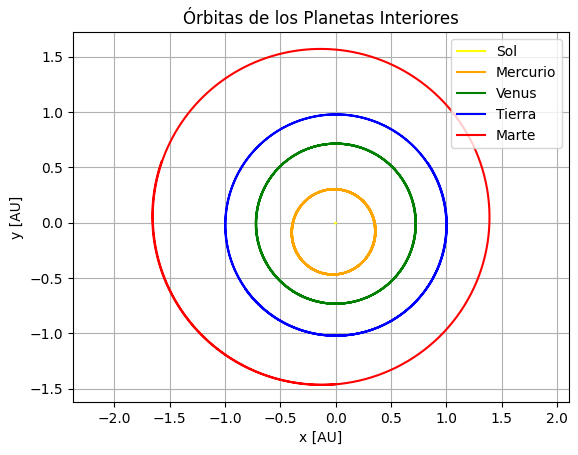

In [ ]:
for i, id_body in enumerate(('10', '199', '299', '399', '499')):
    _, _, Xs = pc.consulta_horizons(
    id = id_body,
    location = '@SSB',
    epochs = epochs1
)
    r = Xs.iloc[:, 0:3].values
    r = r / UL

    x = r[:, 0]
    y = r[:, 1]
    plt.plot(x, y, label=planetas1[i], color=colores1[planetas1[i]])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Órbitas de los Planetas Interiores')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

Definimos un diccionario con los colores que se usarán para graficar la órbita de cada planeta exterior y el Cometa Halley, y la lista planetas2 que contiene los nombres de los planetas exteriores y el Cometa Halley (los cuales estarán en la segunda gráfica). Esta información se usará para graficar la representación 2D de los planetas exteriores y el Cometa Halley.

In [ ]:
colores2 = {
    'Sol': 'yellow',
    'Júpiter': 'magenta',
    'Saturno': 'orange',
    'Urano': 'blue',
    'Neptuno': 'lime',
    'Cometa Halley': 'aqua'
}

planetas2 = ['Sol', 'Júpiter', 'Saturno', 'Urano',
             'Neptuno', 'Cometa Halley']

Nuevamente mediante un ciclo for, se obtienen de horizons las posiciones del Sol, los planetas exteriores y el Cometa Halley centradas en el baricentro durante cada día del intervalo de tiempo epochs2, se convierten las posiciones a unidades astronómicas y se grafican las componentes $x$ de las posiciones vs las componentes $y$. Finalmente, se obtiene la representación 2D para los planetas exteriores y el Cometa Halley.

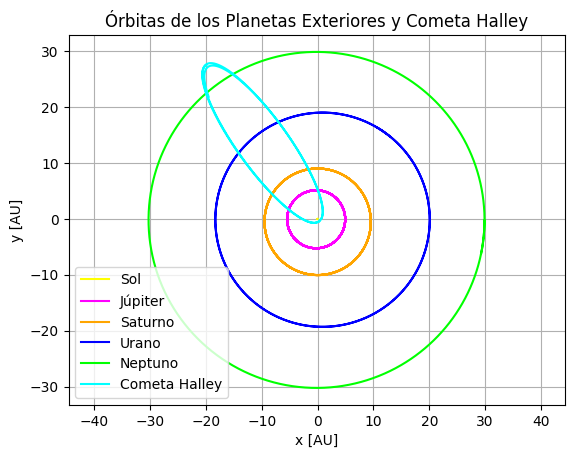

In [ ]:
for i, id_body in enumerate(('10', '599', '699', '799',
                             '899', '90000001')):
    _, _, Xs = pc.consulta_horizons(
    id = id_body,
    location = '@SSB',
    epochs = epochs2
)
    r = Xs.iloc[:, 0:3].values
    r = r / UL

    x = r[:, 0]
    y = r[:, 1]
    plt.plot(x, y, label = planetas2[i], color = colores2[planetas2[i]])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Órbitas de los Planetas Exteriores y Cometa Halley')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

Como gráfico adicional, se repite el mismo procedimiento anterior con todos los planetas, con el fin de obtener una representación 2D de todo el sistema solar y apreciar mejor su escala.

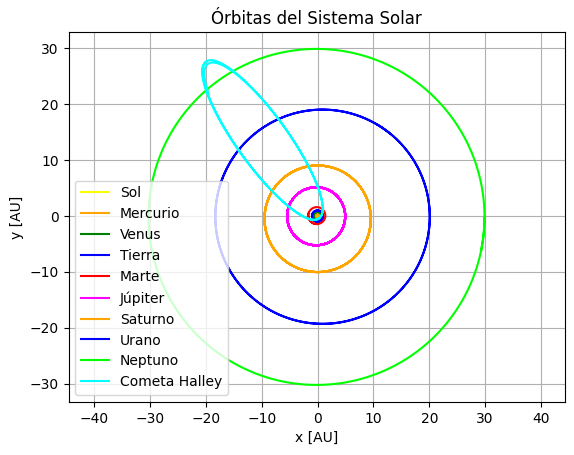

In [ ]:
for i, id_body in enumerate(('10', '199', '299', '399', '499')):
    _, _, Xs = pc.consulta_horizons(
    id = id_body,
    location =' @SSB',
    epochs = epochs1
)
    r = Xs.iloc[:, 0:3].values
    r = r / UL

    x = r[:, 0]
    y = r[:, 1]
    plt.plot(x, y, label = planetas1[i], color = colores1[planetas1[i]])

for i, id_body in enumerate(('599', '699', '799',
                             '899', '90000001')):
    _, _, Xs = pc.consulta_horizons(
    id = id_body,
    location = '@SSB',
    epochs = epochs2
)
    r = Xs.iloc[:, 0:3].values
    r = r / UL

    x = r[:, 0]
    y = r[:, 1]
    plt.plot(x, y, label = planetas2[i+1], color = colores2[planetas2[i+1]])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Órbitas del Sistema Solar')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

# **2. Momentum Angular del Sistema Solar**


Se obtienen las masas del Sol y de los planetas del Sistema Solar, se convierten a unidades de masas solares y se guardan como variables. Posteriormente se crea una lista para guardar todas las masas.

In [ ]:
M_sol = (pc.constantes.mu_sun / pc.constantes.G) / UM
M_mercurio = (pc.constantes.mu_mercury / pc.constantes.G) / UM
M_venus = (pc.constantes.mu_venus / pc.constantes.G) / UM
M_tierra = (pc.constantes.mu_earth / pc.constantes.G) / UM
M_marte = (pc.constantes.mu_mars / pc.constantes.G) / UM
M_jupiter = (pc.constantes.mu_jupiter / pc.constantes.G) / UM
M_saturno = (pc.constantes.mu_saturn / pc.constantes.G) / UM
M_urano = (pc.constantes.mu_uranus / pc.constantes.G) / UM
M_neptuno = (pc.constantes.mu_neptune / pc.constantes.G) / UM

M = [M_sol, M_mercurio, M_venus, M_tierra, M_marte, M_jupiter,
     M_saturno, M_urano, M_neptuno]

Inicialmente se define la variable en la que se guardará el momentum angular total del sistema y se iguala a cero.

Mediante un ciclo for, se consultan las posiciones y velocidades de cada cuerpo con respecto al centro de masa del Sistema Solar en el momento de mi nacimiento (15 de febrero de 2004). Se convierten las posiciones y velocidades al sistema de unidades que se está utilizando y se calcula el momentum angular de cada cuerpo con la fórmula $L = m \vec{r} \times \vec{v}$.

Al calcular el momentum angular individual de cada cuerpo, se van sumando al momentum angular total del Sistema Solar. Así, al finalizar el ciclo for, se tendrá el momentum angular total del Sistema Solar.

In [ ]:
Ltot = 0

for i, id_body in enumerate(('10', '199', '299', '399', '499', '599',
                             '699', '799', '899')):
    _, _, Xs = pc.consulta_horizons(
    id = id_body,
    location =' @0',
    epochs = '2004-02-15 20:00:00'
)

    r = Xs[0:3] / UL
    v = Xs[3:6] / UV
    L = M[i] * np.cross(r, v)
    Ltot += L

Se imprime el resultado del momentum angular total, tanto en el sistema de unidades definido inicialmente como en el sistema internacional de unidades.

In [ ]:
print(f"L nuevo sistema de unidades = {Ltot}")
print(f"L sistema internacional = {Ltot*UH}")

L nuevo sistema de unidades = [0.00058345 0.00018482 0.02220603]
L sistema internacional = [8.22722015e+41 2.60620899e+41 3.13129355e+43]


Puesto que las respuestas a las siguientes preguntas son ángulos, se define una función que convierte grados al formato de grados, minutos y segundos para una mejor comprensión de los resultados

In [ ]:
def conversion_angulos(angulo):
    grados = int(angulo)
    minutos = int((abs(angulo - grados)) * 60)
    segundos = round(((abs(angulo - grados)) * 60 - minutos) * 60, 2)

    if angulo < 0:
        grados = -abs(grados)

    return grados, minutos, segundos

Para determinar las coordenadas ecuatoriales absolutas a las cuales apunta el vector del momentum angular, debemos inicialmente encontrar las coordenadas eclípticas a las que apunta.

Las coordenadas eclípticas $\lambda$ y $\beta$ están dadas por:


$\tan{\lambda} = \frac{L_y}{L_x}$

$\sin{\beta} = \frac{L_z}{\mid L \mid}$

A partir de estas fórmulas, encontramos las coordenadas eclípticas a las que apunta el vector.

In [ ]:
longitud = np.arctan(Ltot[1] / Ltot[0])
longitud = longitud * 180 / np.pi

grados, minutos, segundos = conversion_angulos(longitud)
print(f"Longitud Eclíptica = {grados}° {minutos}' {segundos}\"")

beta = np.arcsin(Ltot[2] / np.linalg.norm(Ltot))
beta = beta * 180 / np.pi

grados, minutos, segundos = conversion_angulos(beta)
print(f"Latitud Eclíptica = {grados}° {minutos}' {segundos}\"")

Longitud Eclíptica = 17° 34' 37.55"
Latitud Eclíptica = 88° 25' 16.58"


Para convertir a coordenadas ecuatoriales absolutas, utilizamos las fórmulas de conversión encontradas en el libro *Elementos de Astronomía de Posición* de Héctor Portilla:

$\sin{\delta} = \sin{\beta} \cos{\epsilon} + \cos{\beta}\sin{\epsilon}\sin{\lambda}$

$\tan{\alpha} = \frac{-\sin{\beta}\sin{\epsilon}+\cos{\beta}\cos{\epsilon}\sin{\lambda}}{\sin{\lambda}\sin{\beta}}$

Donde $\epsilon$ corresponde a la oblicuidad de la eclíptica. Además se tiene que:

$\alpha$ es de la forma $\tan{\alpha}= \tan^{-1}{\left( \frac{p}{q} \right)}$, y el ángulo verdadero se encuentra según las reglas:

Si $p \cdot q < 0$ y $q<0$ entonces $\alpha = \alpha + 180$

Si $p \cdot q < 0$ y $q>0$ entonces $\alpha = \alpha + 360$

Si $p+q<0$ entonces $\alpha = \alpha + 180$

Teniendo en cuenta las fórmulas anteriores, creamos una función que convierte coordenadas eclípticas en coordenadas ecuatoriales absolutas.

In [ ]:
def coordenadas_ecuatoriales(long_eclip, lat_eclip):
    epsilon = 23.44 # oblicuidad de la eclíptica

    # radianes
    epsilon = epsilon * np.pi / 180
    long_eclip = long_eclip * np.pi / 180
    lat_eclip = lat_eclip * np.pi / 180

    # conversión
    sin_delta = (np.cos(epsilon) * np.sin(lat_eclip) + np.sin(epsilon)
                 * np.cos(lat_eclip) * np.sin(long_eclip))
    delta = np.arcsin(sin_delta)

    p = (- np.sin(lat_eclip) * np.sin(epsilon) + np.cos(lat_eclip)
         * np.cos(epsilon) * np.sin(long_eclip))
    q = np.cos(lat_eclip) * np.cos(long_eclip)

    tan_alpha = p / q
    alpha = np.arctan(tan_alpha)

    if p * q < 0 and q < 0:
        alpha = alpha + np.pi
    elif p * q < 0 and q > 0:
        alpha = alpha + 2*np.pi
    elif p + q < 0:
        alpha = alpha + np.pi
    else:
        alpha = alpha

    # grados
    delta = delta * 180 / np.pi
    alpha = alpha * 180 / np.pi

    return alpha, delta

Ahora se aplica la función a las coordenadas encontradas anteriormente, y se obtienen las coordenadas ecuatoriales absolutas a las cuales apunta el vector de momentum angular total del sistema solar. Se convierte $\alpha$ a horas, minutos y segundos para imprimir.

In [ ]:
alpha, delta = coordenadas_ecuatoriales(longitud, beta)

horas = int(alpha / 15)
minutos = int((alpha / 15 - horas) * 60)
segundos = round((((alpha / 15 - horas) * 60) - minutos) * 60, 2)

print(f"Ascensión Recta = {horas} horas {minutos} min {segundos} sec")

grados, minutos, segundos = conversion_angulos(delta)
print(f"Declinación = {grados}° {minutos}' {segundos}\"")

Ascensión Recta = 18 horas 15 min 24.64 sec
Declinación = 66° 59' 24.96"


Para determinar la inclinación entre el vector momentum angular y el eje de rotación de la tierra, debemos recordar que el eje de rotación de la tierra coincide con el polo norte celeste. Por lo tanto, el ángulo entre el vector y el eje de rotación será la diferencia de declinaciones entre el polo norte y la encontrada para el vector

In [ ]:
inclinacion_eje = 90 - delta
grados, minutos, segundos = conversion_angulos(inclinacion_eje)
print(
    f"Inclinación con el eje de rotación de la Tierra = {grados}° "
    f"{minutos}' {segundos}\""
)

Inclinación con el eje de rotación de la Tierra = 23° 0' 35.04"


El vector normal a la orbita de la tierra coincide con el polo norte eclíptico, por lo tanto el ángulo entre el vector momentum angular y el vector normal a la órbita de la tierra será la diferencia de declinaciones eclípticas entre el polo norte eclíptico y la encontrada para el vector.

In [ ]:
inclinacion_normal_orbita = 90 - beta

grados, minutos, segundos = (
    conversion_angulos(inclinacion_normal_orbita))
print(
    f"Inclinación con el vector normal a la órbita de la Tierra = "
    f"{grados}° {minutos}' {segundos}\""
)

Inclinación con el vector normal a la órbita de la Tierra = 1° 34' 43.42"


Otra manera de obtener dicho ángulo es calculando la inclinación del Plano Invariable de Laplace respecto a la eclíptica, de la forma $i = \cos^{-1}{\frac{L_z}{L}}$. Se evidencia que, efectivamente, ambos ángulos coinciden.

In [ ]:
i = np.arccos(Ltot[2] / np.linalg.norm(Ltot))
i = i * 180 / np.pi

grados, minutos, segundos = conversion_angulos(i)
print(
    f"Inclinación del Plano Invariable de Laplace con la Eclíptica "
    f"(equivalente al ángulo con el vector normal a la órbita de la "
    f"Tierra) = {grados}° {minutos}' {segundos}\""
)

Inclinación del Plano Invariable de Laplace con la Eclíptica (equivalente al ángulo con el vector normal a la órbita de la Tierra) = 1° 34' 43.42"


Finalmente, para determinar el ángulo de los planos de cada una de las órbitas de los planetas respecto al Plano Invariable de Laplace, podemos determinar el ángulo entre el vector de momentum angular total del sistema solar y los vectores de momentum angular individuales de cada planeta (ambos vectores respecto al baricentro), puesto que dicho ángulo será equivalente al ángulo entre los planos.

Inicialmente calculamos y guardamos en un array los vectores de momentum angular de cada planeta.

In [ ]:
Ls = np.zeros((8, 3))
for i, id_body in enumerate(('199', '299', '399', '499', '599',
                             '699', '799', '899')):
    _, _, Xs = pc.consulta_horizons(
    id = id_body,
    location =' @0',
    epochs = '2004-02-15 20:00:00'
)

    r = Xs[0:3] / UL
    v = Xs[3:6] / UV
    Ls[i, :] = M[i] * np.cross(r, v)

Se calcula en ángulo entre el vector del momentum angular total con los vectores de momentum angular individuales usando el producto punto. Se guardan los ángulos obtenidos en un array.

In [ ]:
angulos = np.zeros(8)

for i in range(8):
    cos_angulo = (np.dot(Ls[i, :], Ltot) /
     (np.linalg.norm(Ls[i, :]) * np.linalg.norm(Ltot)))
    angulo = np.arccos(cos_angulo)
    angulo = angulo * 180 / np.pi

    angulos[i] = angulo

Se guarda una lista con los nombres de los planetas para posteriormente imprimir los ángulos obtenidos

In [ ]:
planetas = ['Mercurio', 'Venus', 'Tierra', 'Marte', 'Júpiter',
            'Saturno', 'Urano', 'Neptuno']
print(
    "Ángulos entre las órbitas de los planetas y el"
    "Plano Invariable de Laplace"
)

for i in range(8):
    grados, minutos, segundos = conversion_angulos(angulos[i])
    print(f"{planetas[i]} = {grados}° {minutos}' {segundos}\"")

Ángulos entre las órbitas de los planetas y elPlano Invariable de Laplace
Mercurio = 6° 17' 13.24"
Venus = 2° 11' 59.93"
Tierra = 1° 34' 48.13"
Marte = 1° 40' 55.23"
Júpiter = 0° 19' 37.04"
Saturno = 0° 56' 2.39"
Urano = 1° 1' 37.35"
Neptuno = 0° 43' 23.43"


# **3. Posición de los planetas con el método de Euler, Dalembert, RK45 y Radau**

Obtenemos la posición y velocidad inicial de los planetas para el 15 de febrero de 2004 y las convertimos al sistema de unidades que se está usando. Se guardan en los arreglos rs y vs.

In [ ]:
rs = np.zeros((9,3))
vs = np.zeros((9,3))
vs2 = np.zeros((9,3))

for i, id_body in enumerate(('10', '199', '299', '399', '499', '599',
                             '699', '799', '899')):
    _, _, Xs = pc.consulta_horizons(
    id = id_body,
    location = ' @0',
    epochs = '2004-02-15 20:00:00'
)
    rs[i] = Xs[0:3] / UL
    vs[i] = Xs[3:6] / UV

Nuevamente se define la lista con las masas de los planetas y las listas planetas1, planetas2 y colores, que serán útiles para graficar las posiciones de los planetas encontradas mediante los diferentes métodos.

In [ ]:
M = [M_sol, M_mercurio, M_venus, M_tierra, M_marte, M_jupiter,
     M_saturno, M_urano, M_neptuno]
planetas1 = ['Mercurio', 'Venus', 'Tierra', 'Marte']
planetas2 = ['Jupiter', 'Saturno', 'Urano', 'Neptuno']
colores = ['orange', 'green', 'blue', 'red', 'magenta', 'lime', 'aqua',
           'blueviolet']

Se define el $Δt$ en años que se usa para integrar mediante los métodos de Euler y Dalembert, y a partir de este se encuentra el número de pasos que se deben realizar para completar la integración durante 30 años.

In [ ]:
deltat = 0.003
Nt = int(30 / deltat)

Método de Euler

Se crean los cubos de datos en los cuales se guardarán los valores encontrados de posición, velocidad y energía cinética para cada uno de los cuerpos en cada uno de los pasos.

In [ ]:
rs_euler = np.zeros((9, Nt, 3))
vs_euler = np.zeros((9, Nt, 3))
energias_euler = np.zeros((9, Nt, 1))

Se guardan las condiciones iniciales obtenidas anteriormente para cada cuerpo en el tiempo 0 de cada cubo de datos.

In [ ]:
for planeta in range(9):
    rs_euler[planeta, 0] = rs[planeta]
    vs_euler[planeta, 0] = vs[planeta]
    energias_euler[planeta, 0] = ((1 / 2) * M[planeta]
                                  * np.linalg.norm(vs[planeta]) ** 2)

Se integra utilizando las ecuaciones vistas en clase para el método de Euler. En cada tiempo se calcula la posición y velocidad de cada cuerpo teniendo en cuenta la influencia de los demás, y de allí se calcula su energía cinética. Se van guardando los datos obtenidos en el cubo de datos.

Ecuaciones Método de Euler:

$\left\{
\begin{aligned}
\vec{r}_i(t_0 + \Delta t) &\approx \vec{r}_i(t_0) + \vec{v}_i(t_0) \Delta t \\
\vec{v}_i(t_0 + \Delta t) &\approx \vec{v}_i(t_0) - \sum_{j \ne i} \frac{\mu_j}{r_{ij}(t_0)^2} \vec{r}_{ij}(t_0) \Delta t
\end{aligned}
\right\}_N$

In [ ]:
# Para cada tiempo:
for t in range(Nt - 1):

    # Para cada planeta:
    for cuerpo in range(9):
        r_cuerpo = rs_euler[cuerpo,t].copy()
        v_cuerpo = vs_euler[cuerpo,t].copy()
        masa_cuerpo = M[cuerpo]

        # contribución de los demás cuerpos
        sumatoria = np.zeros(3)
        for i in range(9):
            if i != cuerpo:
                r2 = rs_euler[i,t].copy()
                v2 = vs_euler[i,t].copy()
                masa = M[i]

                sumatoria += (-G2 * masa * (r_cuerpo - r2)
                              / np.linalg.norm(r_cuerpo - r2) ** 3 * deltat)

        # nuevas velocidades y posiciones
        r_cuerpo = r_cuerpo + v_cuerpo * deltat
        v_cuerpo = v_cuerpo + sumatoria

        rs_euler[cuerpo, t + 1] = r_cuerpo
        vs_euler[cuerpo, t + 1] = v_cuerpo
        energias_euler[cuerpo, t + 1] = ((1 / 2) * masa_cuerpo
                                         * np.linalg.norm(v_cuerpo) ** 2)

Se realiza una representación 2D de las órbitas de los planetas interiores durante 30 años obtenidas mediante el método de Euler. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas interiores.

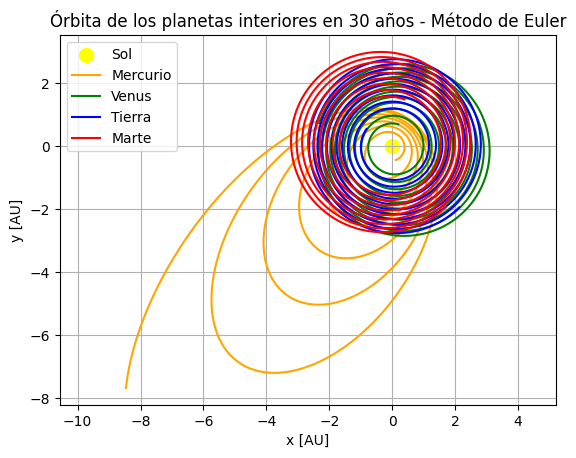

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(1, 5):
    plt.plot(rs_euler[i, :, 0], rs_euler[i, :, 1],
             label = planetas1[i - 1], color = colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas interiores en 30 años - Método de Euler'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

Se realiza una representación 2D de las órbitas de los planetas exteriores durante 30 años obtenidas mediante el método de Euler. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas exteriores.

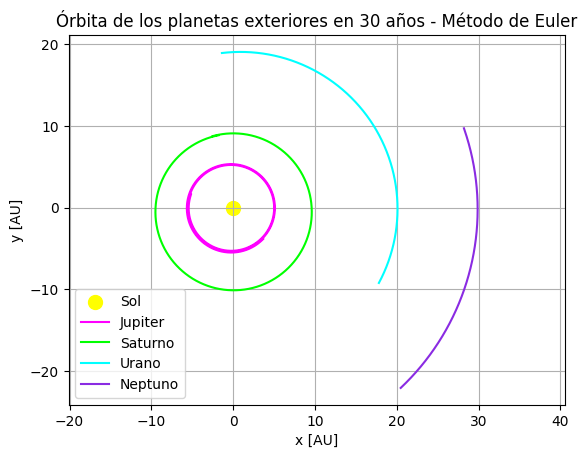

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(5, 9):
    plt.plot(rs_euler[i, :, 0], rs_euler[i, :, 1],
             label = planetas2[i - 5], color = colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas exteriores en 30 años - Método de Euler'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

A partir de los datos de energía cinética obtenidos para cada cuerpo en cada instante de tiempo se calcula la energía cinética total del Sistema Solar al sumar las energías cinéticas individuales de cada cuerpo para cada tiempo. Se obtiene un arreglo con la energía cinética total del sistema para cada tiempo.

La energía cinética total del sistema en cada instante de tiempo está dada por:

$\sum_i \frac{1}{2} m_i \dot{\vec{r}}_i^2$

In [ ]:
energia_cinetica_euler = np.zeros(Nt)
for i in range(Nt):
    for j in range(8):
        energia_cinetica_euler[i] += energias_euler[j,i,0]

A partir de las masas de los planetas y los vectores posición encontrados para cada cuerpo en cada instante de tiempo, se calcula la energía potencial total del sistema solar en cada tiempo.

La energía potencial total del sistema en cada instante de tiempo está dada por:

$U = - \sum_i \sum_{j > i} U_{ij}$

In [ ]:
"""Uso de IA para generar el doble bucle para calcular la energía potencial
total del sistema en cada instante de tiempo.

IA: ChatGPT
Prompt:
Ayúdame a crear un código en Python para calcular la energía potencial total
del sistema solar en un periodo de 30 años, según la imagen (le adjunté la
diapositiva con la fórmula de las sumatorias). Tengo los vectores posición
para el sol y cada planeta durante 300 tiempos en un array de tamaño (9,300,3),
es decir, 9 cuerpos, 300 tiempos y 3 componentes del vector posición.
Necesito la energía potencial total en cada instante de tiempo usando ciclos
for a partir de los datos de mi arreglo.

Este mismo código lo usaré para calcular la energía potencial en los
otros métodos."""

energia_potencial_euler = np.zeros(Nt)

for t in range(Nt):
    U_t = 0

    for i in range(9):
        for j in range(i + 1, 9):
            r_vec = rs_euler[i, t] - rs_euler[j, t]
            r = np.linalg.norm(r_vec)
            U_ij = -G2 * M[i] * M[j] / r
            U_t += U_ij

    energia_potencial_euler[t] = U_t

Para determinar la energía total del sistema, se suman la energía cinética con la energía potencial en cada instante de tiempo. Adicionalmente se crea un arreglo con los tiempos para poder graficar las energías.

La energía total en cada instante de tiempo está dada por:

$E = K + U$

In [ ]:
E_total_euler = energia_cinetica_euler + energia_potencial_euler
tiempo = np.linspace(0, 30, Nt)

Se grafican la energía cinética, energía potencial y energía total del sistema en función del tiempo obtenidas por el Método de Euler. Se observa que las energías cinética y potencial se compensan en cada instante de tiempo, generando que la energía mecánica total del sistema sea aproximadamente constante.

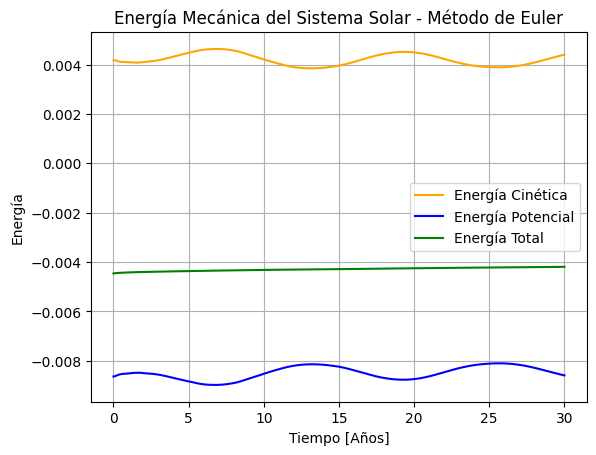

In [ ]:
plt.plot(tiempo, energia_cinetica_euler, label = 'Energía Cinética',
         color = 'orange')
plt.plot(tiempo, energia_potencial_euler, label = 'Energía Potencial',
         color = 'blue')
plt.plot(tiempo, E_total_euler, label = 'Energía Total',
         color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Energía Mecánica del Sistema Solar - Método de Euler")
plt.grid()
plt.show()

Se realiza una gráfica de la energía mecánica total del sistema en función del tiempo, con el fin de observar cómo varía debido al método de integración, pues teóricamente siempre es constante.

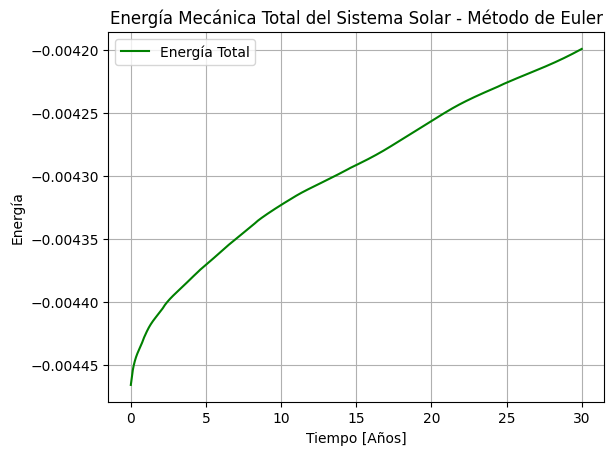

In [ ]:
plt.plot(tiempo, E_total_euler, label = 'Energía Total',
         color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Energía Mecánica Total del Sistema Solar - Método de Euler")
plt.grid()
plt.show()

Método de Dalembert

Se crean los cubos de datos en los cuales se guardarán los valores encontrados de posición, velocidad y energía cinética para cada uno de los cuerpos en cada uno de los pasos.

In [ ]:
rs_dalembert = np.zeros((9, Nt, 3))
vs_dalembert = np.zeros((9, Nt, 3))
energias_dalembert = np.zeros((9, Nt, 1))

Se guardan las condiciones iniciales obtenidas anteriormente para cada cuerpo en el tiempo 0 de cada cubo de datos.

In [ ]:
for planeta in range(9):
    rs_dalembert[planeta, 0] = rs[planeta]
    vs_dalembert[planeta, 0] = vs[planeta]
    energias_dalembert[planeta, 0] = ((1 / 2) * M[planeta]
                                      * np.linalg.norm(vs[planeta]) ** 2)

Se integra utilizando las ecuaciones vistas en clase para el método de Dalembert (Leapfrog). En cada tiempo se calcula la posición y velocidad de cada cuerpo teniendo en cuenta la influencia de los demás, y de allí se calcula su energía cinética. Se van guardando los datos obtenidos en el cubo de datos.

Para el Método de Dalembert:

$\left\{
\begin{aligned}
\vec{v}_i(t_0 + \Delta t) &\approx \vec{v}_i(t_0) - \sum_{j \ne i} \frac{\mu_j}{r_{ij}(t_0)^2} \vec{r}_{ij}(t_0) \Delta t \\
\vec{r}_i(t_0 + \Delta t) &\approx \vec{r}_i(t_0) + \vec{v}_i(t_0 + \Delta t) \Delta t
\end{aligned}
\right\}_N$

In [ ]:
# Para cada tiempo:
for t in range(Nt - 1):

    # Para cada planeta:
    for cuerpo in range(9):
        r_cuerpo = rs_dalembert[cuerpo,t].copy()
        v_cuerpo = vs_dalembert[cuerpo,t].copy()
        masa_cuerpo = M[cuerpo]

        # contribución de los demás cuerpos
        sumatoria = np.zeros(3)
        for i in range(9):
            if i != cuerpo:
                r2 = rs_dalembert[i,t].copy()
                v2 = vs_dalembert[i,t].copy()
                masa = M[i]

                sumatoria += (- G2 * masa * (r_cuerpo - r2)
                / np.linalg.norm(r_cuerpo - r2) ** 3 * deltat)

        # nuevas velocidades y posiciones
        v_cuerpo = v_cuerpo + sumatoria
        r_cuerpo = r_cuerpo + v_cuerpo * deltat

        rs_dalembert[cuerpo, t + 1] = r_cuerpo
        vs_dalembert[cuerpo, t + 1] = v_cuerpo
        energias_dalembert[cuerpo, t + 1] = (
            (1 / 2) * masa_cuerpo * np.linalg.norm(v_cuerpo) ** 2)

Se realiza una representación 2D de las órbitas de los planetas interiores durante 30 años obtenidas mediante el método de Dalembert. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas interiores.

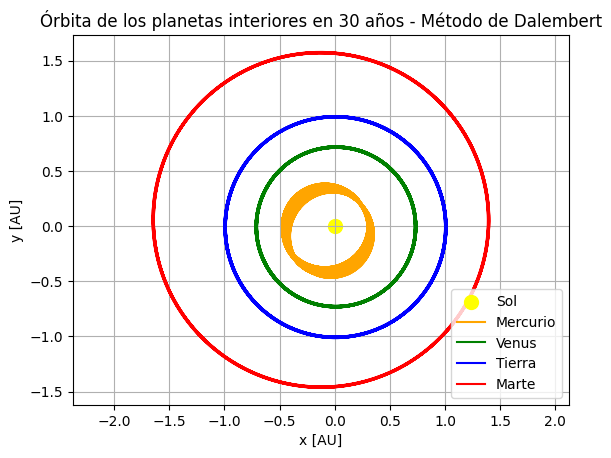

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(1, 5):
    plt.plot(rs_dalembert[i, :, 0], rs_dalembert[i, :, 1],
             label = planetas1[i - 1], color = colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas interiores en 30 años - '
    f'Método de Dalembert'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

Se realiza una representación 2D de las órbitas de los planetas exteriores durante 30 años obtenidas mediante el método de Dalembert. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas exteriores.

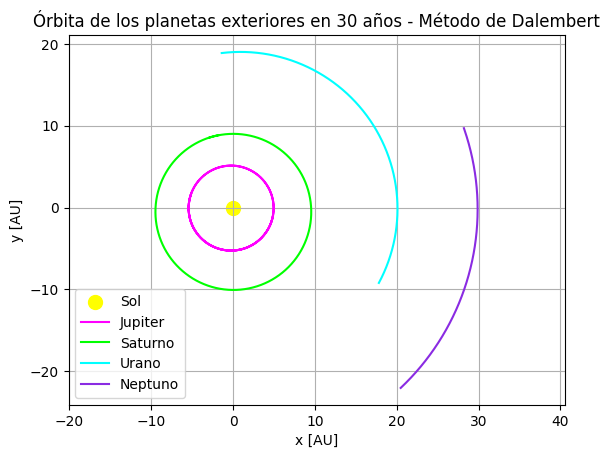

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(5, 9):
    plt.plot(rs_dalembert[i, :, 0], rs_dalembert[i, :, 1],
             label=planetas2[i - 5], color=colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas exteriores en 30 años - '
    f'Método de Dalembert'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

A partir de los datos de energía cinética obtenidos para cada cuerpo en cada instante de tiempo se calcula la energía cinética total del Sistema Solar al sumar las energías cinéticas individuales de cada cuerpo para cada tiempo. Se obtiene un arreglo con la energía cinética total del sistema para cada tiempo.

La energía cinética total del sistema en cada instante de tiempo está dada por:

$\sum_i \frac{1}{2} m_i \dot{\vec{r}}_i^2$

In [ ]:
energia_cinetica_dalembert = np.zeros(Nt)
for i in range(Nt):
    for j in range(8):
        energia_cinetica_dalembert[i] += energias_dalembert[j,i,0]

A partir de las masas de los planetas y los vectores posición encontrados para cada cuerpo en cada instante de tiempo, se calcula la energía potencial total del sistema solar en cada tiempo.

La energía potencial total del sistema en cada instante de tiempo está dada por:

$U = - \sum_i \sum_{j > i} U_{ij}$

In [ ]:
energia_potencial_dalembert = np.zeros(Nt)

for t in range(Nt):
    U_t = 0

    for i in range(9):
        for j in range(i + 1, 9):
            r_vec = rs_dalembert[i, t] - rs_dalembert[j, t]
            r = np.linalg.norm(r_vec)
            U_ij = -G2 * M[i] * M[j] / r
            U_t += U_ij

    energia_potencial_dalembert[t] = U_t

Para determinar la energía total del sistema, se suman la energía cinética con la energía potencial en cada instante de tiempo.

La energía total en cada instante de tiempo está dada por:

$E = K + U$

In [ ]:
E_total_dalembert = (energia_cinetica_dalembert +
                     energia_potencial_dalembert)

Se grafican la energía cinética, energía potencial y energía total del sistema en función del tiempo obtenidas por el Método de Dalembert. Se observa que las energías cinética y potencial se compensan en cada instante de tiempo, generando que la energía mecánica total del sistema sea aproximadamente constante.

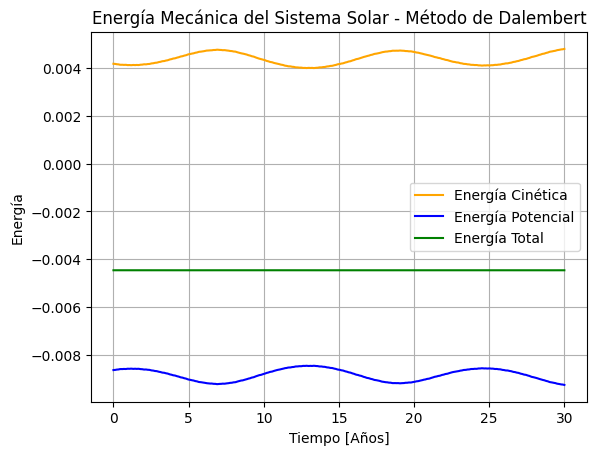

In [ ]:
plt.plot(tiempo, energia_cinetica_dalembert,
         label = 'Energía Cinética', color = 'orange')
plt.plot(tiempo, energia_potencial_dalembert,
         label = 'Energía Potencial', color = 'blue')
plt.plot(tiempo, E_total_dalembert,
         label = 'Energía Total', color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Energía Mecánica del Sistema Solar - Método de Dalembert")
plt.grid()
plt.show()

Se realiza una gráfica de la energía mecánica total del sistema en función del tiempo, con el fin de observar cómo varía debido al método de integración, pues teóricamente siempre es constante.

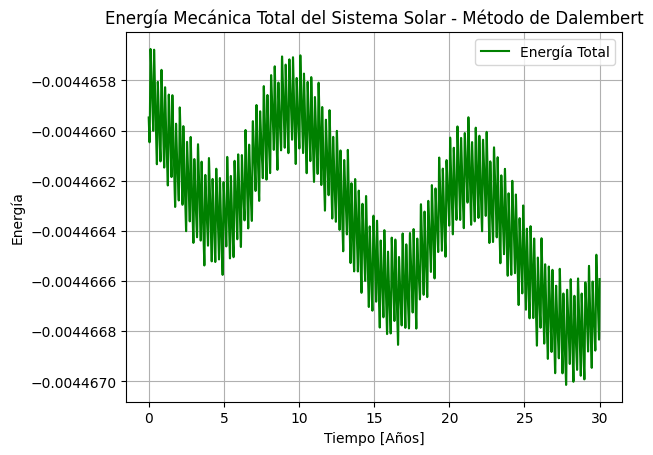

In [ ]:
plt.plot(tiempo, E_total_dalembert, label = 'Energía Total',
         color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title(
    f'Energía Mecánica Total del Sistema Solar - '
    f'Método de Dalembert'
)
plt.grid()
plt.show()

Método RK45

Inicialmente, se unen todas las posiciones iniciales de todos los cuerpos en un sólo vector, y lo mismo se hace para las velocidades iniciales. Posteriormente se unen las posiciones y velocidades en un solo vector Y0 que contiene todas las condiciones iniciales del sistema y se usará para la integración.

In [ ]:
radios = np.concatenate(rs)
velocidades = np.concatenate(vs)

Y0 = np.concatenate((radios, velocidades))

Se define el intervalo de tiempo en el cual se va a integrar. Se crea un array con las masas de los cuerpos y posteriormente se crea todo arreglo que contiene dichas masas multiplicadas por $G$, el cual será utilizado para la integración.

In [ ]:
ts = np.linspace(0, 30, 1000)
M = np.array([M_sol, M_mercurio, M_venus, M_tierra, M_marte, M_jupiter,
              M_saturno, M_urano, M_neptuno])
M2 = M.copy() * G2

Se crean los cubos de datos en los cuales se guardarán los valores encontrados de posición y velocidad para cada uno de los cuerpos en cada uno de los pasos.

In [ ]:
rs_rk45 = np.zeros((9, len(ts), 3))
vs_rk45 = np.zeros((9, len(ts), 3))

Se define una nueva función basada en edm_ncuerpos que sea compatible con el orden de los argumentos que se deben ingresar a solve_ivp. Posteriormente se calcula la solución mediante el método de RK45.

In [ ]:
edm_ncuerpos_buena = lambda t, Y, N, mus: pc.edm_ncuerpos(Y, t, N, mus)

solucion = (solve_ivp(edm_ncuerpos_buena, (ts[0], ts[-1]), Y0, t_eval=ts,
                      args=(9, M2), method='RK45', rtol = 1e-8, atol = 1e-10))

"""Los parámetros rtol y atol se agregan por sugerencia de ChatGPT, puesto
que sin ellos la función no estaba calculando todos los tiempos que se le
estaban solicitando.

Prompt: le pegué mi código y el error que me estaba saliendo
ValueError: could not broadcast input array from shape (212,3) into
shape (1000,3).

Justificación de ChatGPT: se ajustaron las tolerancias del integrador
solve_ivp a valores más estrictos (rtol=1e-8, atol=1e-10), permitiendo
pasos de integración más pequeños y garantizando la estabilidad de la
trayectoria durante los 30 años de simulación requeridos."""
None

Se guardan los resultados de posiciones y velocidad obtenidos para cada cuerpo y tiempo en los arrays definidos inicialmente.

In [ ]:
for i in range(9):
    r_vec = solucion.y[(3 * i):(3 + 3 * i)].T
    v_vec = solucion.y[(27 + 3 * i):(30 + 3 * i)].T

    rs_rk45[i] = r_vec
    vs_rk45[i] = v_vec

Se realiza una representación 2D de las órbitas de los planetas interiores durante 30 años obtenidas mediante el Método de RK45. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas interiores.

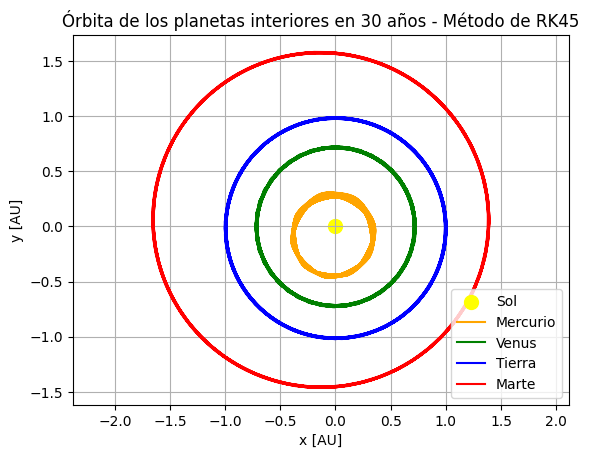

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(1, 5):
    plt.plot(rs_rk45[i, :, 0], rs_rk45[i, :, 1],
             label = planetas1[i - 1], color = colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas interiores en 30 años - '
    f'Método de RK45'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

Se realiza una representación 2D de las órbitas de los planetas exteriores durante 30 años obtenidas mediante el Método de RK45. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas exteriores.

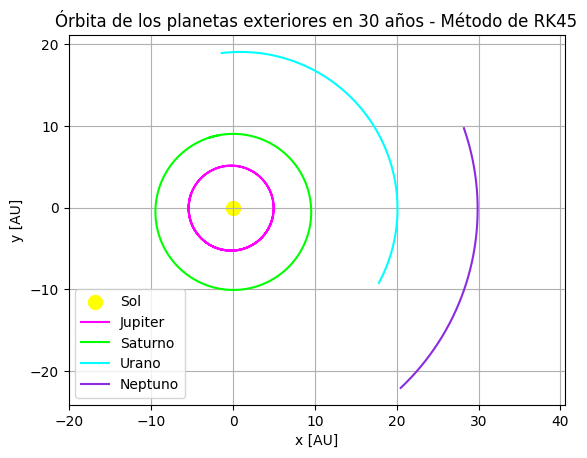

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(5, 9):
    plt.plot(rs_rk45[i, :, 0], rs_rk45[i, :, 1],
             label = planetas2[i - 5], color = colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas exteriores en 30 años - '
    f'Método de RK45'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

A partir de los datos de velocidad calculados es posible obtener las energías cinéticas. Se calcula la energía cinética para cada cuerpo en cada instante de tiempo y se van sumando para obtener la energía cinética total del sistema en cada tiempo.

La energía cinética total del sistema en cada instante de tiempo está dada por:

$\sum_i \frac{1}{2} m_i \dot{\vec{r}}_i^2$

In [ ]:
energia_cinetica_rk45 = np.zeros(len(ts))
for t in range(len(ts)):
    for j in range(9):
        K = (1 / 2) * M[j] * np.linalg.norm(vs_rk45[j, t]) ** 2
        energia_cinetica_rk45[t] += K

A partir de las masas de los planetas y los vectores posición encontrados para cada cuerpo en cada instante de tiempo, se calcula la energía potencial total del sistema solar en cada tiempo.

La energía potencial total del sistema en cada instante de tiempo está dada por:

$U = - \sum_i \sum_{j > i} U_{ij}$

In [ ]:
energia_potencial_rk45 = np.zeros(len(ts))

for t in range(len(ts)):
    U_t = 0

    for i in range(9):
        for j in range(i + 1, 9):
            r_vec = rs_rk45[i, t] - rs_rk45[j, t]
            r = np.linalg.norm(r_vec)
            U_ij = -G2 * M[i] * M[j] / r
            U_t += U_ij

    energia_potencial_rk45[t] = U_t

Para determinar la energía total del sistema, se suman la energía cinética con la energía potencial en cada instante de tiempo. Nuevamente se crea un arreglo con los tiempos para hacer las gráficas de la energía.

La energía total en cada instante de tiempo está dada por:

$E = K + U$

In [ ]:
E_total_rk45 = energia_cinetica_rk45 + energia_potencial_rk45
tiempo = np.linspace(0, 30, len(ts))

Se grafican la energía cinética, energía potencial y energía total del sistema en función del tiempo obtenidas por el Método de RK45. Se observa que las energías cinética y potencial se compensan en cada instante de tiempo, generando que la energía mecánica total del sistema sea aproximadamente constante.

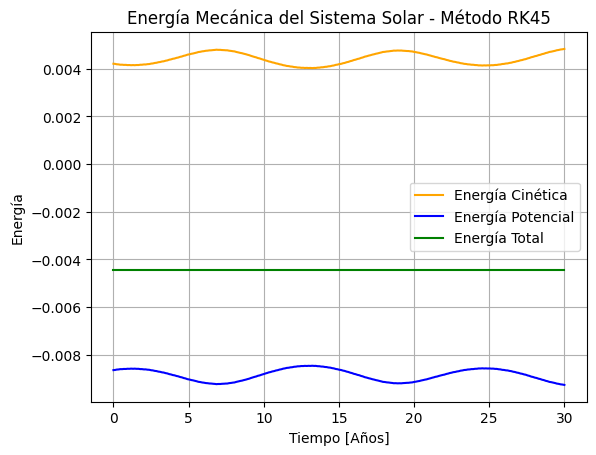

In [ ]:
plt.plot(tiempo, energia_cinetica_rk45,
         label = 'Energía Cinética', color = 'orange')
plt.plot(tiempo, energia_potencial_rk45,
         label = 'Energía Potencial', color = 'blue')
plt.plot(tiempo, E_total_rk45,
         label = 'Energía Total', color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Energía Mecánica del Sistema Solar - Método RK45")
plt.grid()
plt.show()

Se realiza una gráfica de la energía mecánica total del sistema en función del tiempo, con el fin de observar cómo varía debido al método de integración, pues teóricamente siempre es constante.

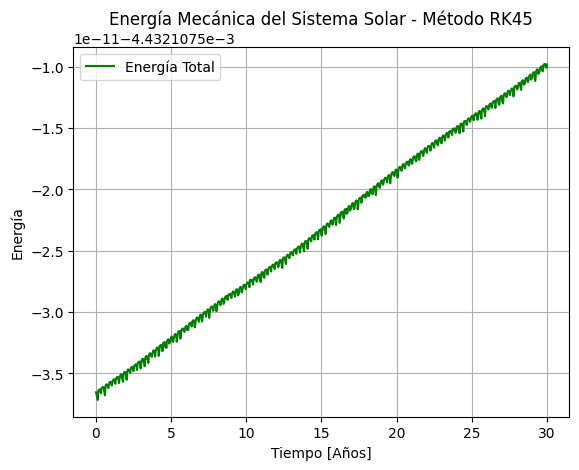

In [ ]:
plt.plot(tiempo, E_total_rk45, label = 'Energía Total',
         color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Energía Mecánica del Sistema Solar - Método RK45")
plt.grid()
plt.show()

Método de Radau

Se usan los mismos arreglos de Y0, M2 y ts utilizados en el método de RK45, por lo que no se vuelven a definir.

Se crean los cubos de datos en los cuales se guardarán los valores encontrados de posición y velocidad para cada uno de los cuerpos en cada uno de los pasos.

In [ ]:
rs_radau = np.zeros((9, len(ts), 3))
vs_radau = np.zeros((9, len(ts), 3))

Se define una nueva función basada en edm_ncuerpos que sea compatible con el orden de los argumentos que se deben ingresar a solve_ivp. Posteriormente se calcula la solución mediante el método de RK45.

In [ ]:
edm_ncuerpos_buena = lambda t, Y, N, mus: pc.edm_ncuerpos(Y, t, N, mus)

solucion = (solve_ivp(edm_ncuerpos_buena, (ts[0], ts[-1]), Y0,
                      t_eval=ts, args=(9, M2), method = 'Radau'))

Se guardan los resultados de posiciones y velocidad obtenidos para cada cuerpo y tiempo en los arrays definidos inicialmente.

In [ ]:
for i in range(9):
    r_vec = solucion.y[(3 * i):(3 + 3 * i)].T
    v_vec = solucion.y[(27 + 3 * i):(30 + 3 * i)].T

    rs_radau[i] = r_vec
    vs_radau[i] = v_vec

Se realiza una representación 2D de las órbitas de los planetas interiores durante 30 años obtenidas mediante el Método de Radau. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas interiores.

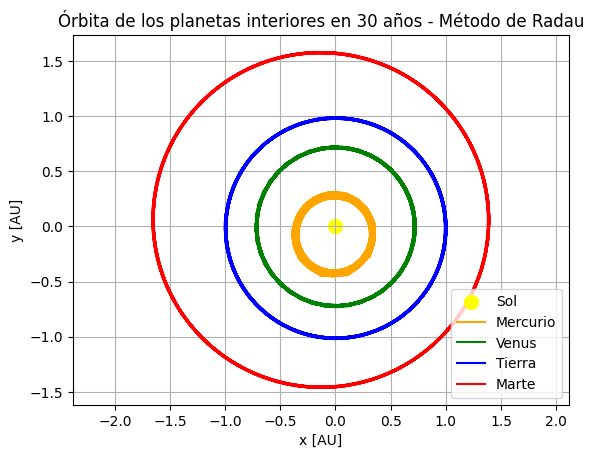

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(1, 5):
    plt.plot(rs_radau[i, :, 0], rs_radau[i, :, 1],
             label = planetas1[i - 1], color = colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas interiores en 30 años - '
    f'Método de Radau'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

Se realiza una representación 2D de las órbitas de los planetas exteriores durante 30 años obtenidas mediante el Método de Radau. Se grafica el Sol en el centro y se grafican las componentes $x$ y $y$ de las posiciones obtenidas para cada uno de los planetas exteriores.

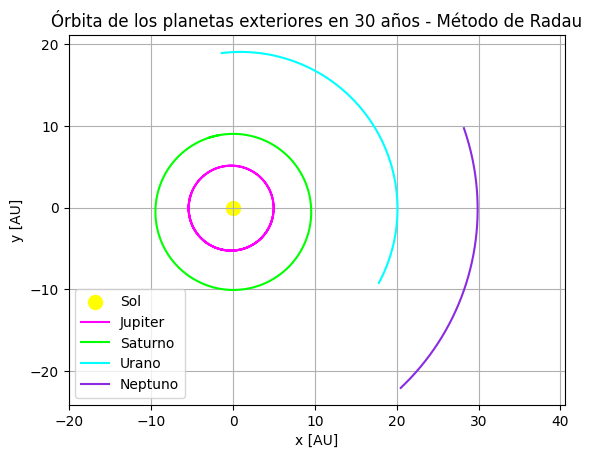

In [ ]:
plt.scatter(0, 0, color = 'yellow', marker = 'o', s = 100,
            label = 'Sol')

for i in range(5, 9):
    plt.plot(rs_radau[i, :, 0], rs_radau[i, :, 1],
             label = planetas2[i - 5], color = colores[i - 1])

plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title(
    f'Órbita de los planetas exteriores en 30 años - '
    f'Método de Radau'
)
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

A partir de los datos de velocidad calculados es posible obtener las energías cinéticas. Se calcula la energía cinética para cada cuerpo en cada instante de tiempo y se van sumando para obtener la energía cinética total del sistema en cada tiempo.

La energía cinética total del sistema en cada instante de tiempo está dada por:

$\sum_i \frac{1}{2} m_i \dot{\vec{r}}_i^2$

In [ ]:
energia_cinetica_radau = np.zeros(len(ts))
for t in range(len(ts)):
    for j in range(9):
        K = (1 / 2) * M[j] * np.linalg.norm(vs_radau[j,t]) ** 2
        energia_cinetica_radau[t] += K

A partir de las masas de los planetas y los vectores posición encontrados para cada cuerpo en cada instante de tiempo, se calcula la energía potencial total del sistema solar en cada tiempo.

La energía potencial total del sistema en cada instante de tiempo está dada por:

$U = - \sum_i \sum_{j > i} U_{ij}$

In [ ]:
energia_potencial_radau = np.zeros(len(ts))

for t in range(len(ts)):
    U_t = 0

    for i in range(9):
        for j in range(i + 1, 9):
            r_vec = rs_radau[i, t] - rs_radau[j, t]
            r = np.linalg.norm(r_vec)
            U_ij = -G2 * M[i] * M[j] / r
            U_t += U_ij

    energia_potencial_radau[t] = U_t

Para determinar la energía total del sistema, se suman la energía cinética con la energía potencial en cada instante de tiempo.

La energía total en cada instante de tiempo está dada por:

$E = K + U$

In [ ]:
E_total_radau = energia_cinetica_radau + energia_potencial_radau

Se grafican la energía cinética, energía potencial y energía total del sistema en función del tiempo obtenidas por el Método de Radau. Se observa que las energías cinética y potencial se compensan en cada instante de tiempo, generando que la energía mecánica total del sistema sea aproximadamente constante.

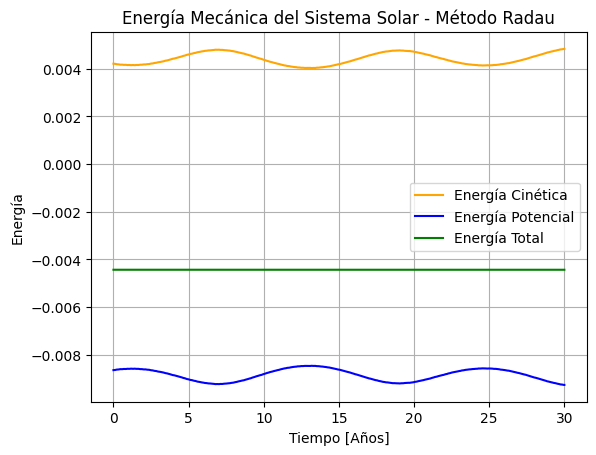

In [ ]:
plt.plot(tiempo, energia_cinetica_radau, label = 'Energía Cinética',
         color = 'orange')
plt.plot(tiempo, energia_potencial_radau, label = 'Energía Potencial',
         color = 'blue')
plt.plot(tiempo, E_total_radau, label = 'Energía Total',
         color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Energía Mecánica del Sistema Solar - Método Radau")
plt.grid()
plt.show()

Se realiza una gráfica de la energía mecánica total del sistema en función del tiempo, con el fin de observar cómo varía debido al método de integración, pues teóricamente siempre es constante.

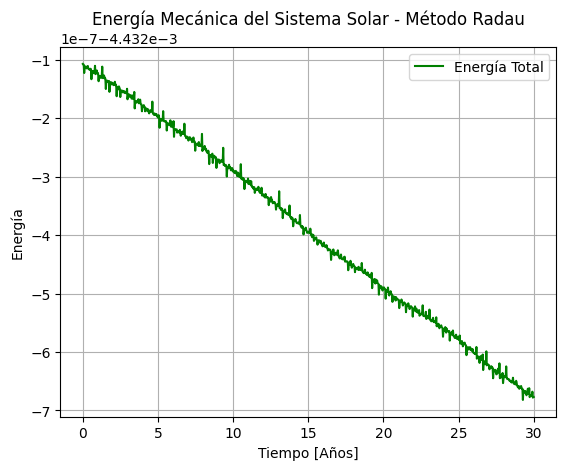

In [ ]:
plt.plot(tiempo, E_total_radau, label = 'Energía Total',
         color = 'green')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Energía Mecánica del Sistema Solar - Método Radau")
plt.grid()
plt.show()

**Análisis:** En las gráficas de energía obtenidas para cada uno de los métodos se observa que la energía cinética y potencial se compensan a lo largo del tiempo, lo cual resulta en que la energía total se mantenga aproximadamente constante durante los 30 años.

En las gráficas de la energía total se pueden evidenciar las pequeñas variaciones en la energía total de cada método, las cuales se dan debido a que los métodos de integración no son perfectos.

Observando cuánto varía la energía total se podría hacer una estimación de cuál método es mejor para integrar la posición de los planetas, siendo RK45 el mejor, seguido por Radau,  Dalembert y por último Euler.

Adicionalmente, de las gráficas obtenidas para las órbitas de los planetas se observa que el método de RK45 y Radau dan muy buenos resultados, seguidos por el método de Dalembert y finalmente el de Euler, el cual presenta órbitas muy imprecisas y alejadas de la realidad

# **4. El Sistema Solar como un sistema de N cuerpos virializado mediante el método de RK45**

Usamos la energía cinética y energía total encontradas por el método de RK45 para determinar la evolución del virial en el tiempo, teniendo en cuenta la ecuación: $\dot G = K + E$. Se utiliza el método RK45 puesto que es el que mejor conserva la energía según las gráficas del punto 3.

In [ ]:
G_punto = energia_cinetica_rk45 + E_total_rk45

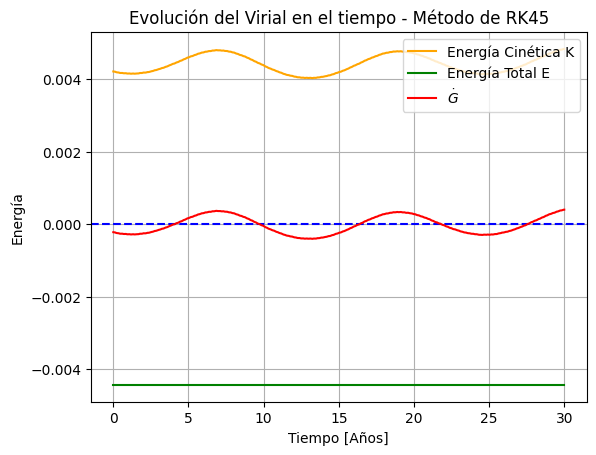

In [ ]:
plt.axhline(0, linestyle = "dashed", color = 'blue')
plt.plot(tiempo, energia_cinetica_rk45, label = 'Energía Cinética K',
         color = 'orange')
plt.plot(tiempo, E_total_rk45, label = 'Energía Total E',
         color = 'green')
plt.plot(tiempo, G_punto, label = '$\dot{G}$', color = 'red')
plt.legend()
plt.xlabel("Tiempo [Años]")
plt.ylabel("Energía")
plt.title("Evolución del Virial en el tiempo - Método de RK45")
plt.grid()
plt.show()

Como $\dot G$ (taza de cambio de $G$) oscila alrededor de cero tomando valores positivos y negativos, se puede afirmar que el Sistema Solar es un sistema de N cuerpos ligado, pues $\dot G$ se mantiene acotada (por lo que el sistema no colapsa ni se dispersa). Se concluye entonces que el Sistema Solar sí es un sistema de N cuerpos virializado, lo cual es evidencia de su estabilidad.